In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

In [4]:
# Transitions matrix
Q = np.array([
    [-0.0085, 0.005, 0.0025, 0, 0.001],
    [0, -0.014, 0.005, 0.004, 0.005],
    [0, 0, -0.008, 0.003, 0.005],
    [0, 0, 0, -0.009, 0.009],
    [0, 0, 0, 0, 0]
])

# Parameters
n_states = len(Q)
n_sims = 1000
states = np.arange(n_states)

# Array to store results
lifetimes = np.zeros(n_sims)

# Random number generator
rng = np.random.default_rng(30)

for i in range(n_sims):
    # Inital parameters
    curr_state = 0

    t = 0

    # Transition to states until death
    while True:
        possible_states = [0,1,2,3,4]
        possible_states.pop(curr_state)

        t += rng.exponential(-1/Q[curr_state,curr_state])

        new_state = rng.choice(a=possible_states, p=-1*(Q[curr_state,possible_states])/(Q[curr_state,curr_state]))

        if (new_state == 4):
            lifetimes[i] = t
            break
        
        # If state is the last state (death) then stop
        if (new_state == 4):
            lifetimes[i] = t
            break
        
        # Update current state
        curr_state = new_state

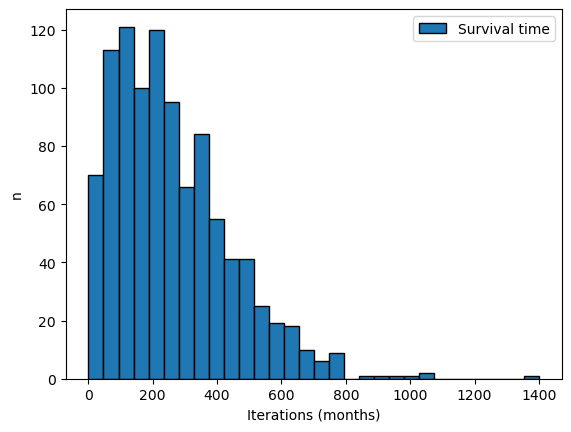

In [5]:
plt.hist(lifetimes,bins=30, edgecolor="black", label="Survival time")
plt.ylabel("n")
plt.xlabel("Iterations (months)")
plt.legend()
plt.show()

In [6]:
np.mean(lifetimes), np.std(lifetimes, ddof=1)

(260.6557758370406, 182.5444358603559)